In [1]:
# 📦 Schritt 1: Bibliotheken importieren
import pandas as pd
import glob
import os

# 📁 Schritt 2: Pfad zu den Metrics-Dateien definieren
folder_path = "/Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solutions_multiple_seeds/"
file_pattern = os.path.join(folder_path, "Metrics_*.csv")

# 📂 Schritt 3: Alle passenden CSV-Dateien finden
file_list = glob.glob(file_pattern)
print(f"{len(file_list)} Dateien gefunden.")

# 📊 Schritt 4: Alle Dateien einlesen und zusammenfügen
all_dfs = [pd.read_csv(file) for file in file_list]
full_df = pd.concat(all_dfs, ignore_index=True)
print("Daten erfolgreich zusammengeführt.")
display(full_df.head())

# 📈 Schritt 5: Durchschnittswerte pro Instanz + Algorithmus berechnen
average_df = full_df.groupby(["Instance", "Algorithm"], as_index=False).mean()
print("Durchschnittswerte berechnet.")
display(average_df.head())

# 💾 Schritt 6: Ergebnis abspeichern
output_path = os.path.join(folder_path, "Metrics_averaged.csv")
average_df.to_csv(output_path, index=False)
print(f"Aggregierte Datei gespeichert unter: {output_path}")

12 Dateien gefunden.
Daten erfolgreich zusammengeführt.


,Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
0,a3_o80_m10_an10_ar9_reduced,PSA,266.52,0.363095,0.807926,0.707341,0.074483,24.561404,0.210609,0.562334
1,a3_o80_m10_an10_ar9_reduced,DBSA,49.70,0.797619,0.156617,0.598938,0.220770,75.438596,0.057933,0.628686
2,a5_o96_m10_an10_ar10_reduced,PSA,193.38,0.424837,0.809439,0.352625,0.224616,18.120805,0.126190,0.416657
3,a5_o96_m10_an10_ar10_reduced,DBSA,42.13,0.872549,0.202595,0.270693,0.296813,81.879195,0.061961,0.673469
4,a10_o107_m5_an57_ar12,PSA,161.17,0.443262,0.335660,0.138177,0.166564,21.097046,0.051928,0.603095


Durchschnittswerte berechnet.


,Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
0,a10_o107_m5_an57_ar12,DBSA,43.873333,0.834974,0.160946,0.347501,0.214566,76.602621,0.053538,0.615909
1,a10_o107_m5_an57_ar12,PSA,167.220000,0.395924,0.613887,0.291220,0.156535,23.397379,0.063678,0.549576
2,a10_o114_m6_an57_ar11,DBSA,57.617500,0.851057,0.156196,0.368579,0.125736,74.824138,0.073002,0.868113
3,a10_o114_m6_an57_ar11,PSA,317.601667,0.464738,0.721289,0.460866,0.119752,25.175862,0.127341,0.866182
4,a10_o128_m6_an51_ar13,DBSA,51.684167,0.847242,0.225774,0.006496,0.189281,77.213126,0.057234,0.884182


Aggregierte Datei gespeichert unter: /Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solutions_multiple_seeds/Metrics_averaged.csv


In [2]:
import pandas as pd

# Datei einlesen (Pfad ggf. anpassen, falls Datei woanders liegt)
df = pd.read_csv("Metrics_averaged.csv")

# Rundung zur besseren Lesbarkeit (optional)
df_rounded = df.round(3)

# Ausgabe als DataFrame mit schöner Formatierung
from IPython.display import display, HTML
display(HTML(df_rounded.to_html(index=False)))

Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
a10_o107_m5_an57_ar12,DBSA,43.873,0.835,0.161,0.348,0.215,76.603,0.054,0.616
a10_o107_m5_an57_ar12,PSA,167.220,0.396,0.614,0.291,0.157,23.397,0.064,0.550
a10_o114_m6_an57_ar11,DBSA,57.618,0.851,0.156,0.369,0.126,74.824,0.073,0.868
a10_o114_m6_an57_ar11,PSA,317.602,0.465,0.721,0.461,0.120,25.176,0.127,0.866
a10_o128_m6_an51_ar13,DBSA,51.684,0.847,0.226,0.006,0.189,77.213,0.057,0.884
a10_o128_m6_an51_ar13,PSA,217.537,0.350,0.542,0.006,0.240,22.787,0.108,0.931
a10_o144_m6_an53_ar12,DBSA,37.171,0.761,0.164,0.488,0.258,63.488,0.074,0.610
a10_o144_m6_an53_ar12,PSA,175.833,0.615,0.354,0.597,0.139,36.512,0.089,0.605
a15_o170_m9_an80_ar18,DBSA,106.031,0.832,0.109,0.040,0.224,77.231,0.039,0.831
a15_o170_m9_an80_ar18,PSA,410.278,0.451,0.273,0.108,0.187,22.769,0.059,0.870


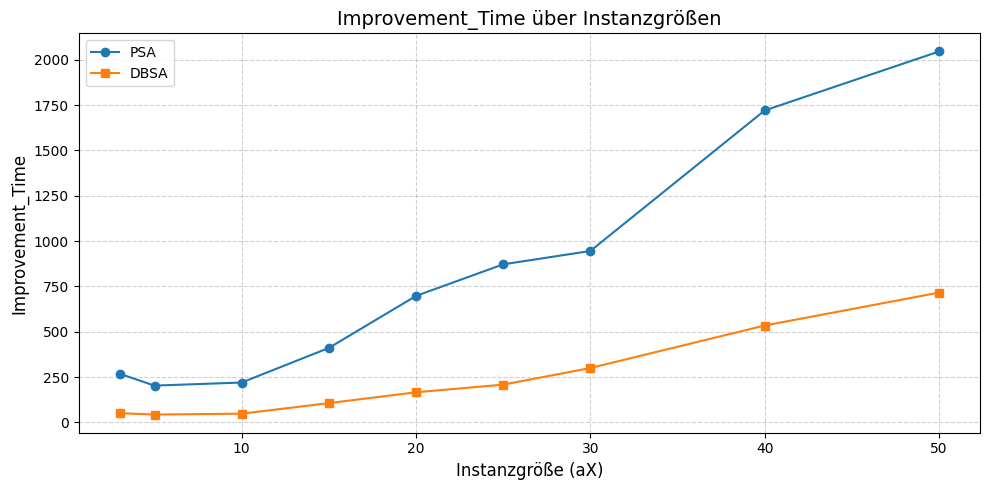

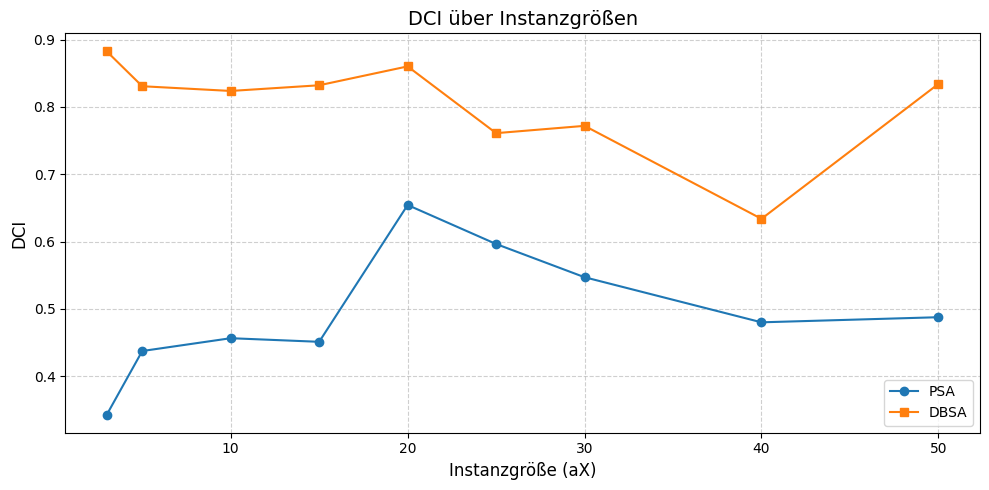

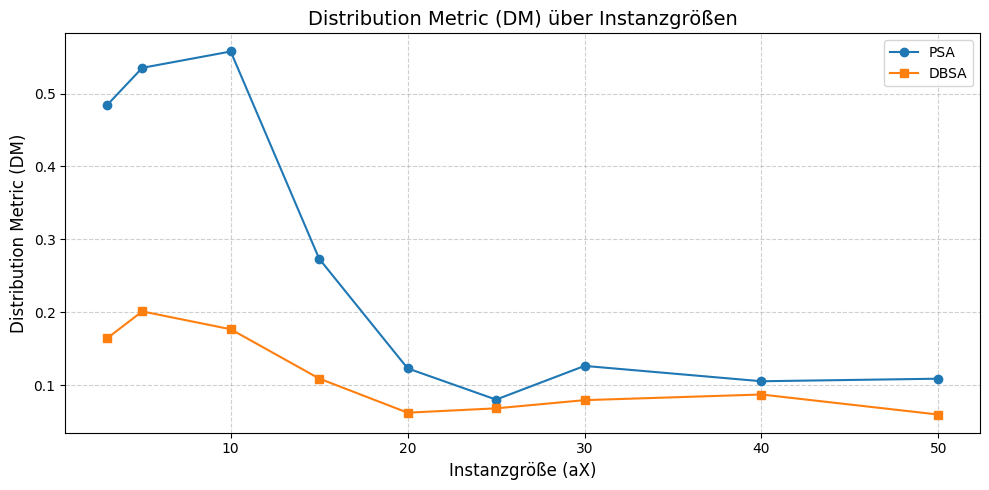

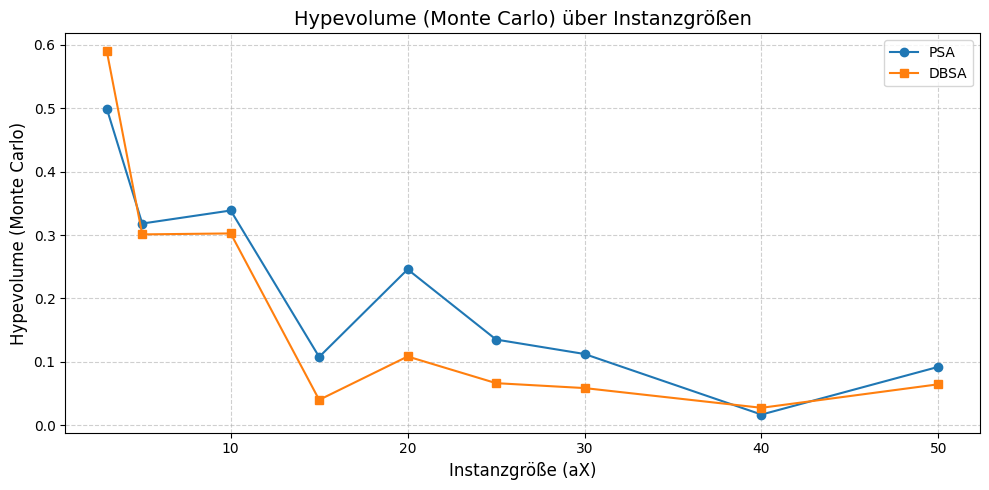

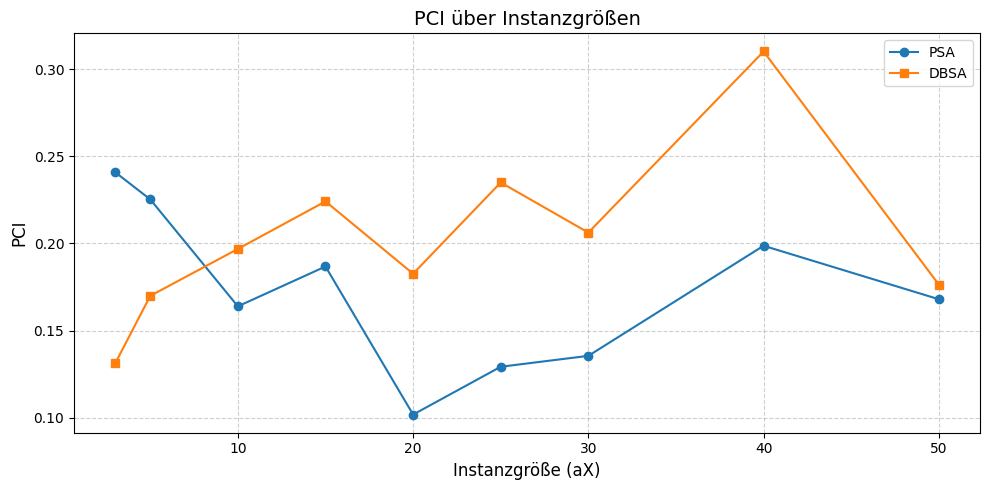

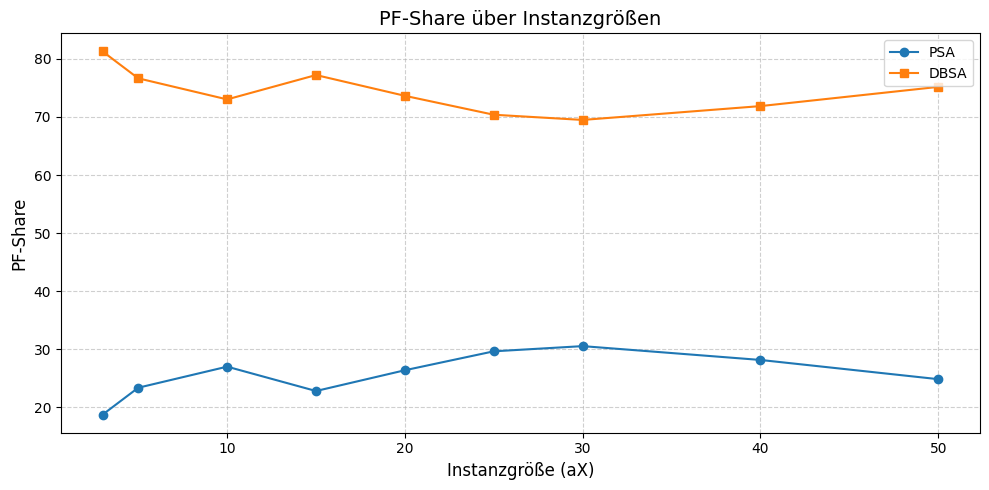

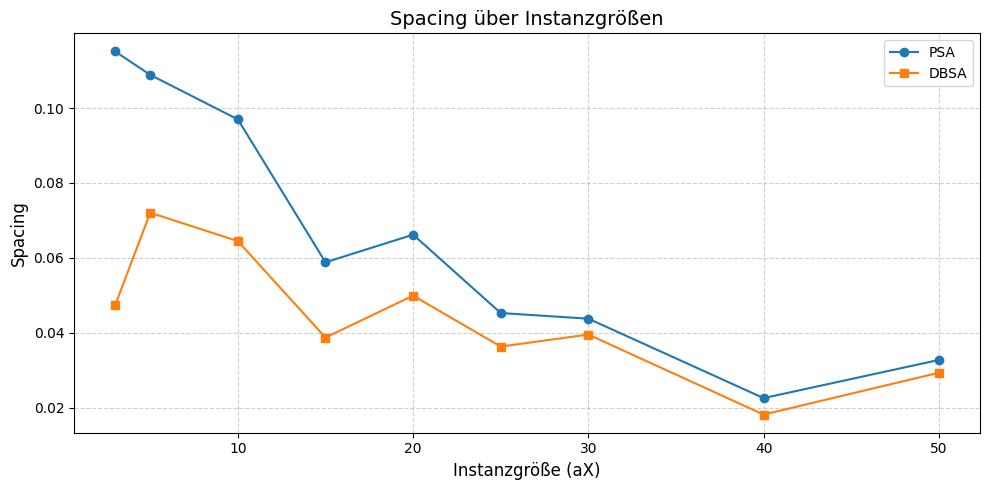

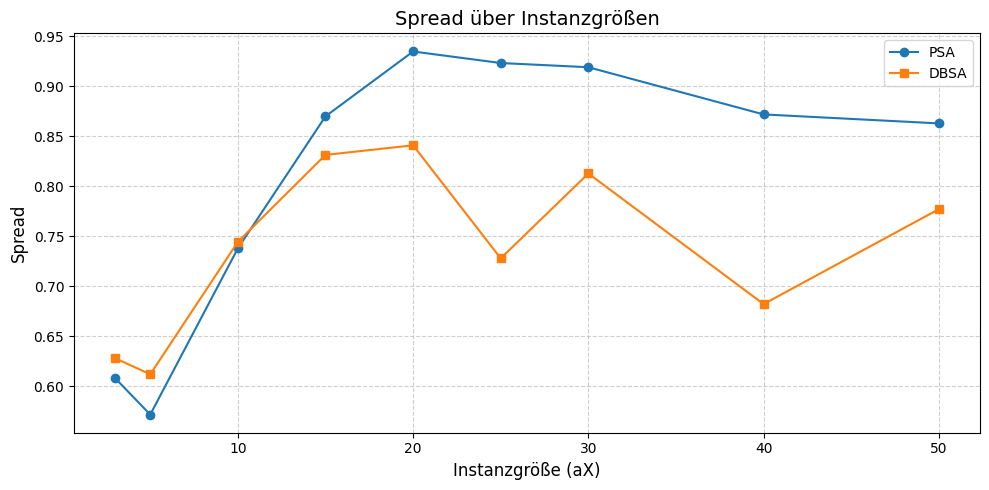

In [3]:
# 📦 Imports
import pandas as pd
import matplotlib.pyplot as plt

# 📂 Datei einlesen
file_path = "/Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solutions_multiple_seeds/Metrics_averaged.csv"
df = pd.read_csv(file_path)

# 🔍 Instanzgröße extrahieren (z. B. 'a3_o80' → 3)
df["Instance_Size"] = df["Instance"].str.extract(r"a(\d+)_").astype(int)

# 🧹 Metriken auswählen (alle außer 'Instance', 'Algorithm', 'Instance_Size')
metrics = [col for col in df.columns if col not in ["Instance", "Algorithm", "Instance_Size"]]

# 🧮 Mittelwert pro (Instance_Size, Algorithm)
agg_df = df.groupby(["Instance_Size", "Algorithm"], as_index=False)[metrics].mean()

# 📊 Sortieren nach Instanzgröße
agg_df = agg_df.sort_values("Instance_Size")

# 🎨 Visualisierung: Jede Metrik als eigenes Diagramm
for metric in metrics:
    plt.figure(figsize=(10, 5))

    # PSA-Linie
    psa_data = agg_df[agg_df["Algorithm"] == "PSA"]
    plt.plot(psa_data["Instance_Size"], psa_data[metric], marker="o", label="PSA")

    # DBSA-Linie
    dbsa_data = agg_df[agg_df["Algorithm"] == "DBSA"]
    plt.plot(dbsa_data["Instance_Size"], dbsa_data[metric], marker="s", label="DBSA")

    # ✨ Formatierung
    plt.title(f"{metric} über Instanzgrößen", fontsize=14)
    plt.xlabel("Instanzgröße (aX)", fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [4]:
# Durchschnittswerte je Algorithmus
df.groupby("Algorithm").mean(numeric_only=True).round(3)

,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread,Instance_Size
Algorithm,,,,,,,,,
DBSA,192.680,0.808,0.128,0.206,0.202,73.993,0.049,0.741,19.0
PSA,669.869,0.485,0.339,0.240,0.170,26.007,0.073,0.793,19.0


In [5]:
# Standardabweichungen je Algorithmus
df.groupby("Algorithm").std(numeric_only=True).round(3)

,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread,Instance_Size
Algorithm,,,,,,,,,
DBSA,220.929,0.068,0.057,0.203,0.052,4.655,0.018,0.108,14.623
PSA,631.410,0.101,0.232,0.196,0.048,4.655,0.035,0.157,14.623
